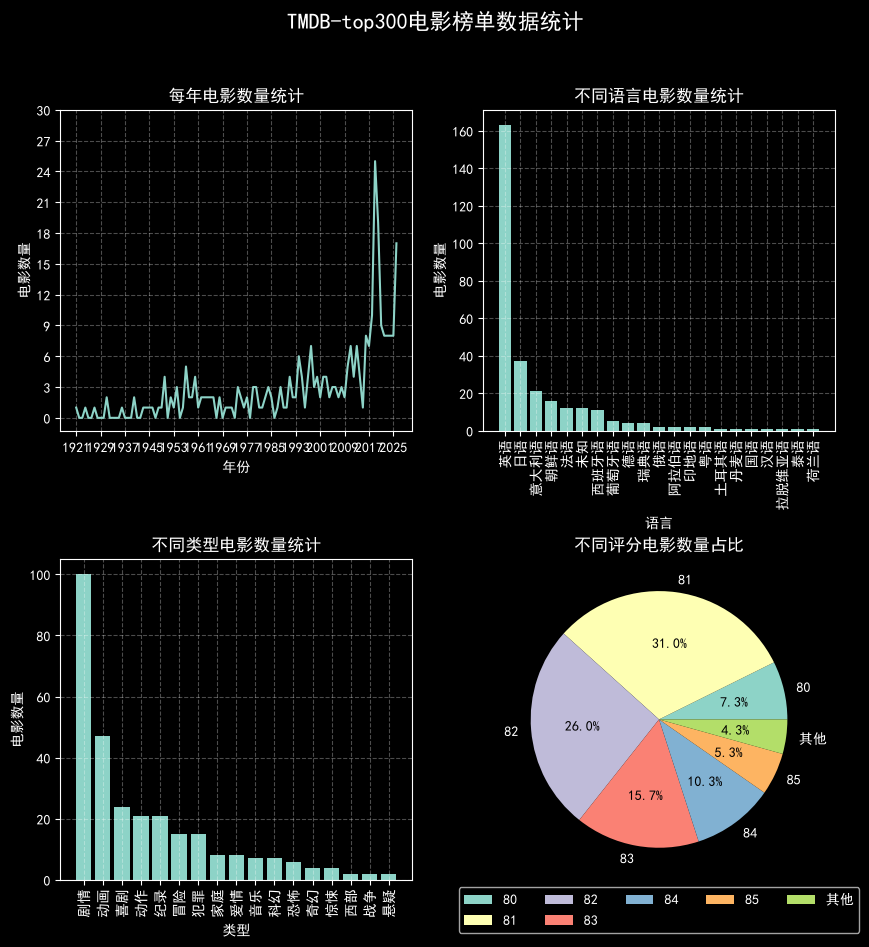

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
#展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

#创建子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
fig.suptitle('TMDB-top300电影榜单数据统计', fontsize=16, fontweight='bold')
fig.subplots_adjust(hspace=0.4, wspace=0.2)

#获取子图
axes1 = axes[0, 0]
axes2 = axes[0, 1]
axes3 = axes[1, 0]
axes4 = axes[1, 1]

#加载数据电影名,年份,上映时间,类型,时长,评分,语言
#int64 ：整型数字（不支持空值）;
#Int64 ：整型数字（支持空值）
#float64 ：浮点型数字（支持空值）;
df = pd.read_csv('csv_data/movie_list.csv', usecols=['电影名', '年份', '上映时间', '类型', '时长', '评分', '语言'],dtype={'年份': 'Int64'})
#折线图统计每年电影数量
#1.数据清洗
#1.1缺失值，异常值处理
df['年份'] = df['年份'].fillna(df['上映时间'].str[:4])

#1.2分组统计
year_count = df.groupby('年份')['年份'].count()

#1.3组装数据
#x轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year, max_year+1)]

#y轴数据
y = [year_count.get(i, 0) for i in x]

#2.绘制折线图
axes1.plot(x, y)
axes1.set_xlabel('年份')
axes1.set_ylabel('电影数量')
axes1.set_title('每年电影数量统计')

axes1.set_xticks(x[::8])#设置x轴刻度
y_ticks = [i for i in range(0, 31, 3)]#设置y轴刻度
axes1.set_yticks(y_ticks)#设置y轴刻度
axes1.grid(linestyle='--',alpha = 0.3)
#2.柱状图统计不同语言电影数量
#2.1数据清洗。用print(df.isnull().sum())来验证语言列没有空值
# 2.1 识别语言列的脏数据
money_mask = df['语言'].astype(str).str.startswith('$')   # 金额污染
dash_mask  = df['语言'] == '-'                              # 缺失占位符
# print('金额污染:', money_mask.sum(), '| 缺失标记:', dash_mask.sum())
# print(df.loc[money_mask, ['电影名', '语言']])

# 2.2 手动修正金额污染的电影语言
fix_map = {
    '火遮眼': '粤语',            # 港产片，实际以英语对白为主，可按需改成'英语'
    '哪吒之魔童闹海': '国语',
    'Top Gun: Maverick': '英语',
}
for name, lang in fix_map.items():
    df.loc[df['电影名'] == name, '语言'] = lang

# 2.3 处理缺失标记：统一归为'未知'（或按电影手动补，见下）
df.loc[dash_mask, '语言'] = '未知'
df.loc[df['语言'] == 'Cantonese', '语言'] = '粤语'   # 统一中文命名

#2.2获取不同语言电影数量
language_count = df.groupby('语言')['语言'].count().sort_values(ascending=False)
#print(language_count)
#绘制柱状图
axes2.bar(language_count.index, language_count.values)

axes2.set_xlabel('语言')
axes2.set_ylabel('电影数量')
axes2.set_title('不同语言电影数量统计')
axes2.grid(linestyle='--',alpha = 0.3)
axes2.tick_params(axis='x', rotation=90)

#3.柱状图统计不同类型电影数量，一部电影的类型可能有多个
type_count = {}
for types in df['类型'].dropna().str.split(','):
    for type in types:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1
type_count = dict(sorted(type_count.items(), key=lambda x: x[1], reverse=True))
#绘制柱状图
axes3.bar(type_count.keys(), type_count.values())

axes3.set_xlabel('类型')
axes3.set_ylabel('电影数量')
axes3.set_title('不同类型电影数量统计')
axes3.grid(linestyle='--',alpha = 0.3)
axes3.tick_params(axis='x', rotation=90)

#饼状图展示不同评分电影数量占比
#1.统计数量
scores_count = df.groupby('评分')['评分'].count()

#2.合并小数据
total = scores_count.sum()
large_scores: pd.Series = scores_count.loc[scores_count > total * 0.02]
small_scores:pd.Series = scores_count.loc[scores_count <= total * 0.02]
large_scores['其他'] = small_scores.sum()

scores = large_scores.index.tolist()
counts = large_scores.values.tolist()
#3.绘制饼状图,和百分数的颜色
patches, texts, autotexts = axes4.pie(
    counts,
    labels=scores,
    autopct='%1.1f%%',
)

for at in autotexts:                    # autotexts 才是百分数文本对象
    at.set_color('black')
    at.set_fontsize(10)
axes4.set_title('不同评分电影数量占比')
axes4.legend(scores, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0))

#4.保存图片
plt.savefig('csv_data/TMDB-top300电影榜单数据统计.png')
plt.show()
